In [ ]:
import random
import datetime

In [340]:

# 1. Criar dados simulados para ordens

orders = []
base_price = 280
for i in range(100):
    price = base_price - i*2 + random.randint(-10, 10)  # tendência de alta
    order = {
        "type": random.choice(["buy", "sell"]),
        "price": price,
        "amount": random.randint(50, 505),
        "maximum": price + random.randint(20, 50),
        "minimum": price - random.randint(20, 50),
        "volume": random.randint(800, 2000),
        "time": datetime.datetime.now() + datetime.timedelta(seconds=i)
    }
    orders.append(order)

# Visualizar preços simulados
prices = [o["price"] for o in orders]
print(prices)

[284, 281, 282, 275, 280, 263, 265, 275, 263, 271, 250, 265, 260, 249, 260, 243, 253, 249, 239, 247, 246, 231, 233, 224, 240, 240, 236, 225, 229, 229, 216, 210, 219, 209, 203, 209, 205, 202, 210, 212, 190, 193, 198, 203, 196, 196, 195, 179, 180, 174, 172, 188, 183, 179, 172, 171, 161, 173, 159, 158, 164, 166, 164, 148, 143, 151, 142, 148, 145, 133, 134, 128, 133, 131, 126, 128, 133, 132, 117, 123, 121, 123, 108, 104, 120, 116, 103, 98, 104, 97, 92, 89, 97, 90, 84, 90, 97, 95, 92, 92]


In [142]:
#pegar o último preço e tempo
last_order = orders[-1]
price_current = last_order["price"]
time_current = last_order["time"]

print("Último preço:", price_current)
print("Tempo da última ordem:", time_current)

Último preço: 101
Tempo da última ordem: 2026-09-30 02:00:27.360160


In [256]:
# ===============Função de onda Ψ=============== #
# 1. Separar ordens de compra e venda
def wave_function(orders):
    buy = [o["amount"] for o in orders if o["type"] == "buy"]
    sell = [o["amount"] for o in orders if o["type"] == "sell"]


    # 2. Calcular médias
    media_buy = sum(buy) / len(buy) if buy else 0
    media_sell = sum(sell) / len(sell) if sell else 0

    # 3. Calcular probabilidades
    higher_probability_buy = sum(1 for q in buy if q > media_buy) / len(buy) if buy else 0
    higher_probability_sell = sum(1 for q in sell if q > media_sell) / len(sell) if sell else 0

    return {
             "buy": higher_probability_buy,
             "sell":higher_probability_sell
            }

higher_probability = wave_function(orders)
print("Probabilidade ordem de compra > média:",higher_probability.get("buy"))
print("Probabilidade ordem de venda > média:",higher_probability.get("sell"))

Probabilidade ordem de compra > média: 0.5555555555555556
Probabilidade ordem de venda > média: 0.5833333333333334


In [238]:
# Função para calcular - Energia cinética (velocidade do preço)
def calculate_kinetic_energy(orders):
    energy = []
    for i in range(1, len(orders)):
        price_current = orders[i]["price"]
        price_previous = orders[i-1]["price"]
        time_current = orders[i]["time"]
        time_previous = orders[i-1]["time"]
        vol_current = orders[i]["volume"]

        # ΔP e Δt
        delta_price = price_current - price_previous
        delta_time = (time_current - time_previous).total_seconds()

        # Energia cinética ~ (vol * ΔP^2 / Δt)
        if delta_time > 0:
            e_c = (vol_current * delta_price **2) / delta_time
            energy.append(e_c)
        else:                        
            energy.append(0)

    return energy

energy_kinetic = calculate_kinetic_energy(orders)

# Mostrar resultados
for i, e in enumerate(energy_kinetic, start=1):
    print(f"Ordem {i}: Energia cinética = {e}")

        

Ordem 1: Energia cinética = 11618.686295470023
Ordem 2: Energia cinética = 15535.844641553584
Ordem 3: Energia cinética = 20047.83961728306
Ordem 4: Energia cinética = 1223.9914320599755
Ordem 5: Energia cinética = 3471.972224222206
Ordem 6: Energia cinética = 93299.44020335878
Ordem 7: Energia cinética = 6859.958840246959
Ordem 8: Energia cinética = 152036.0877834733
Ordem 9: Energia cinética = 0.0
Ordem 10: Energia cinética = 16959.898240610557
Ordem 11: Energia cinética = 27247.80926533514
Ordem 12: Energia cinética = 40774.714576997954
Ordem 13: Energia cinética = 53164.68101191393
Ordem 14: Energia cinética = 41435.75138549169
Ordem 15: Energia cinética = 14498.898507710444
Ordem 16: Energia cinética = 9773.941356351863
Ordem 17: Energia cinética = 3411.9761161671863
Ordem 18: Energia cinética = 40130.75921544471
Ordem 19: Energia cinética = 21855.82515339877
Ordem 20: Energia cinética = 17378.878347851565
Ordem 21: Energia cinética = 9683.932212474512
Ordem 22: Energia cinética =

In [307]:
#Função para calcular energia potencial
def calculate_Potential_energy(orders, max_expansao_pct=0.1):
    if not orders:
        return []

    p_min = orders[0]["price"]
    p_max = orders[0]["price"]
    track_volume = 0
    energies = []

    for o in orders:
        price = o["price"]
        vol = o["volume"]

        nova_min = min(p_min, price)
        nova_max = max(p_max, price)
        amplitude_atual = p_max - p_min
        amplitude_nova = nova_max - nova_min

        # Se a expansão for pequena → ainda é consolidação
        if amplitude_atual == 0 or (amplitude_nova - amplitude_atual) / max(amplitude_atual, 1e-9) <= max_expansao_pct:
            p_min, p_max = nova_min, nova_max
            track_volume += vol
            e_p = (p_max - p_min) * track_volume
            energies.append(e_p)
        else:
            # Rompeu → fecha a consolidação e reinicia
            energies.append(0)
            p_min = p_max = price
            track_volume = vol

    return energies


# Calcular energia potencial
potential_energy = calculate_Potential_energy(orders)

# Mostrar resultados
for i, e in enumerate(potential_energy, start=1):
    print(f"Ordem {i}: Energia potencial = {e}")


Ordem 1: Energia potencial = 0
Ordem 2: Energia potencial = 17368
Ordem 3: Energia potencial = 0
Ordem 4: Energia potencial = 26870
Ordem 5: Energia potencial = 0
Ordem 6: Energia potencial = 20160
Ordem 7: Energia potencial = 0
Ordem 8: Energia potencial = 20153
Ordem 9: Energia potencial = 28539
Ordem 10: Energia potencial = 0
Ordem 11: Energia potencial = 15610
Ordem 12: Energia potencial = 0
Ordem 13: Energia potencial = 36140
Ordem 14: Energia potencial = 56320
Ordem 15: Energia potencial = 0
Ordem 16: Energia potencial = 10244
Ordem 17: Energia potencial = 0
Ordem 18: Energia potencial = 50001
Ordem 19: Energia potencial = 76318
Ordem 20: Energia potencial = 0
Ordem 21: Energia potencial = 13664
Ordem 22: Energia potencial = 24178
Ordem 23: Energia potencial = 0
Ordem 24: Energia potencial = 6189
Ordem 25: Energia potencial = 0
Ordem 26: Energia potencial = 5682
Ordem 27: Energia potencial = 0
Ordem 28: Energia potencial = 2264
Ordem 29: Energia potencial = 0
Ordem 30: Energia po

In [296]:
# Constante de Planck
def calculate_planck_constant(orders, alpha=0.1):
    # Extrair volumes
    volumes = [o["volume"] for o in orders]
    
    # Calcular média exponencial (EMA)
    ema = [volumes[0]]
    for v in volumes[1:]:
        ema.append(alpha * v + (1 - alpha) * ema[-1])
    
    # Constante de Planck do mercado = último valor da EMA
    h_market = ema[-1]
    return h_market, ema

h_market, ema_series = calculate_planck_constant(orders)

print("Constante de Planck (mercado):", h_market)

Constante de Planck (mercado): 1291.8409733553103


In [ ]:
# Evolução de função de onda
def evolve_wave_function(orders, h_market):
    # Função de onda inicial
    psi = wave_function(orders)
    psi_buy = psi["buy"]
    psi_sell = psi["sell"]

    kinetic = calculate_kinetic_energy(orders)
    potential = calculate_Potential_energy(orders)

    evolution = []
    for i in range(min(len(kinetic), len(potential))):
        H = kinetic[i] + potential[i]
        price_current = orders[i]["price"]
        price_previous = orders[i-1]["price"] if i > 0 else price_current

        # Drift proporcional à variação de preço
        drift = (price_current - price_previous) / max(price_previous,1)

        # Oscilação senoidal (interferência quântica)
        oscillation = 0.05 * np.sin(i * 0.3)  # amplitude 0.05, frequência 0.3

        # Atualização com viés + oscilação
        psi_buy += (H / h_market) * 0.1 * (1 + drift) + oscillation
        psi_sell += (H / h_market) * 0.1 * (1 - drift) - oscillation

        # Normalização
        total = psi_buy + psi_sell
        psi_buy /= total
        psi_sell /= total

        # Limitar entre 0 e 1
        psi_buy = max(0, min(1, psi_buy))
        psi_sell = max(0, min(1, psi_sell))

        evolution.append({"ordem": i+1, "psi_buy": psi_buy, "psi_sell": psi_sell, "H": H, "oscillation": oscillation})

    return evolution

# Evoluir função de onda
evolution_series = evolve_wave_function(orders, h_market)

# Mostrar resultados
for e in evolution_series:
    print(f"Ordem {e['ordem']}: Ψ_buy={e['psi_buy']:.4f}, Ψ_sell={e['psi_sell']:.4f}, H={e['H']:.2f}")


Ordem 1: Ψ_buy=0.4972, Ψ_sell=0.5028, H=15731.67
Ordem 2: Ψ_buy=0.5012, Ψ_sell=0.4988, H=10791.99
Ordem 3: Ψ_buy=0.5039, Ψ_sell=0.4961, H=76533.56
Ordem 4: Ψ_buy=0.4943, Ψ_sell=0.5057, H=47174.72
Ordem 5: Ψ_buy=0.5099, Ψ_sell=0.4901, H=260108.29
Ordem 6: Ψ_buy=0.5165, Ψ_sell=0.4835, H=5951.96
Ordem 7: Ψ_buy=0.5065, Ψ_sell=0.4935, H=140865.18
Ordem 8: Ψ_buy=0.5198, Ψ_sell=0.4802, H=199006.81
Ordem 9: Ψ_buy=0.4817, Ψ_sell=0.5183, H=130207.42
Ordem 10: Ψ_buy=0.5151, Ψ_sell=0.4849, H=723247.30
Ordem 11: Ψ_buy=0.4625, Ψ_sell=0.5375, H=309821.90
Ordem 12: Ψ_buy=0.5247, Ψ_sell=0.4753, H=85314.71
Ordem 13: Ψ_buy=0.4909, Ψ_sell=0.5091, H=234243.01
Ordem 14: Ψ_buy=0.4783, Ψ_sell=0.5217, H=240391.98
Ordem 15: Ψ_buy=0.5210, Ψ_sell=0.4790, H=496055.09
Ordem 16: Ψ_buy=0.4675, Ψ_sell=0.5325, H=192298.65
Ordem 17: Ψ_buy=0.5112, Ψ_sell=0.4888, H=64407.78
Ordem 18: Ψ_buy=0.4913, Ψ_sell=0.5087, H=215319.02
Ordem 19: Ψ_buy=0.4784, Ψ_sell=0.5216, H=109375.34
Ordem 20: Ψ_buy=0.5045, Ψ_sell=0.4955, H=28186.9

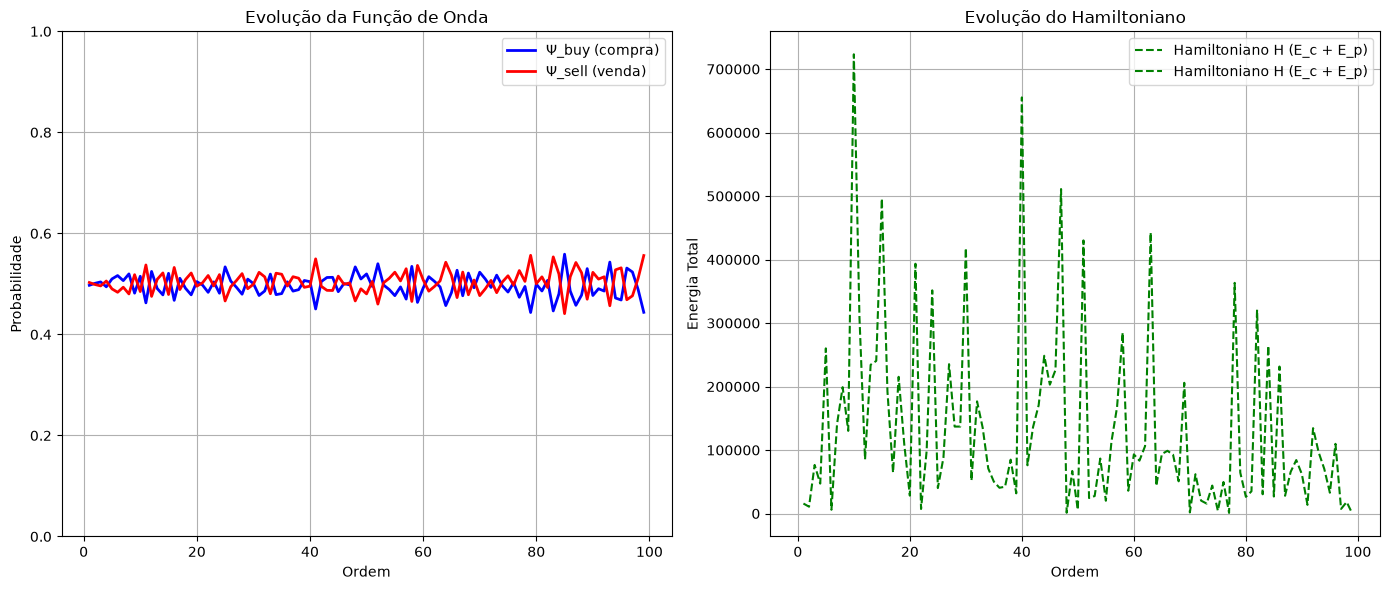

In [ ]:
import matplotlib.pyplot as plt

# Evolução já calculada
evolution_series = evolve_wave_function(orders, h_market)

# Extrair dados
ordens = [e["ordem"] for e in evolution_series]
psi_buy = [e["psi_buy"] for e in evolution_series]
psi_sell = [e["psi_sell"] for e in evolution_series]
hamiltoniano = [e["H"] for e in evolution_series]

# Criar gráfico
plt.figure(figsize=(12,6))

# Probabilidades
plt.plot(ordens, psi_buy, label="Ψ_buy (probabilidade de compra)", color="blue", linewidth=2)
plt.plot(ordens, psi_sell, label="Ψ_sell (probabilidade de venda)", color="red", linewidth=2)

# Hamiltoniano
plt.plot(ordens, hamiltoniano, label="Hamiltoniano H (E_c + E_p)", color="green", linestyle="--")

# Configurações
plt.title("Evolução da Função de Onda e Hamiltoniano")
plt.xlabel("Ordem")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.show()

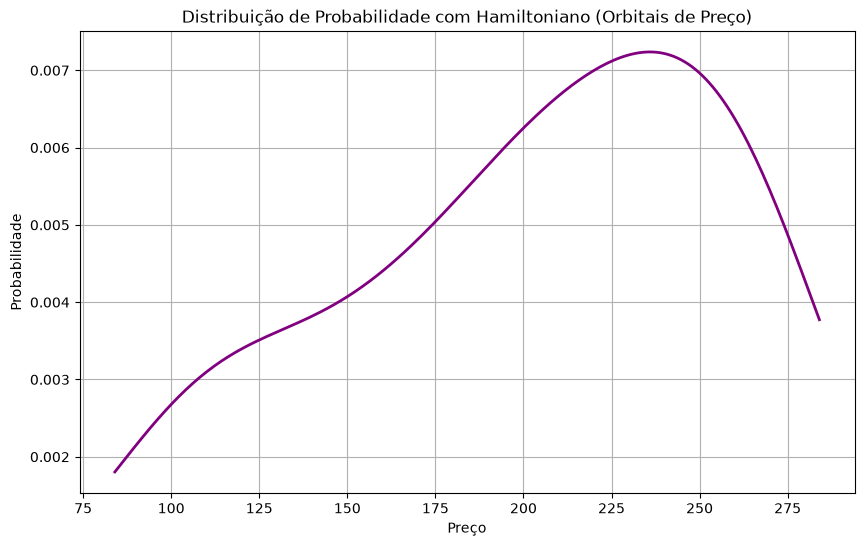

In [403]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

#Distribuição de Probabilidade com Hamiltoniano (Orbitais de Preço)
def price_probability_distribution_kde_hamiltonian(orders):
    prices = np.array([o["price"] for o in orders])
    volumes = np.array([o["volume"] for o in orders])

    # Energias
    kinetic = calculate_kinetic_energy(orders)
    potential = calculate_Potential_energy(orders)
    hamiltonian = np.array([k + p for k, p in zip(kinetic, potential)])

    # Pesos = volume * energia
    weights = volumes[:len(hamiltonian)] * hamiltonian

    # Estimativa de densidade com pesos
    kde = gaussian_kde(prices[:len(weights)], weights=weights)
    x_grid = np.linspace(prices.min(), prices.max(), 200)
    probabilities = kde(x_grid)

    # Normalizar
    probabilities /= probabilities.sum()

    return x_grid, probabilities

# Calcular distribuição suave com Hamiltoniano
x_grid, probabilities = price_probability_distribution_kde_hamiltonian(orders)

# Plotar
plt.figure(figsize=(10,6))
plt.plot(x_grid, probabilities, color="purple", linewidth=2)
plt.title("Distribuição de Probabilidade com Hamiltoniano (Orbitais de Preço)")
plt.xlabel("Preço")
plt.ylabel("Probabilidade")
plt.grid(True)
plt.show()


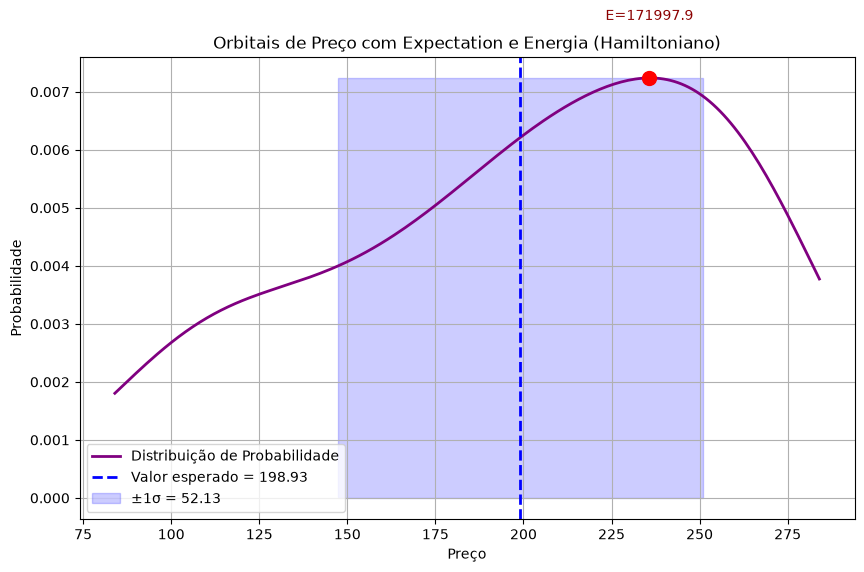

Picos detectados (orbitais de preço):
Preço ~ 235.76, Probabilidade ~ 0.0072, Energia média ~ 171997.91


In [387]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def expectation_and_variance(x_grid, probabilities):
    expectation = np.sum(x_grid * probabilities)
    variance = np.sum(((x_grid - expectation) ** 2) * probabilities)
    std_dev = np.sqrt(variance)
    return expectation, variance, std_dev

# Calcular expectation e variância
expectation, variance, std_dev = expectation_and_variance(x_grid, probabilities)

# Detectar picos locais
peaks, _ = find_peaks(probabilities)
peak_prices = x_grid[peaks]
peak_probs = probabilities[peaks]

# Calcular Hamiltoniano médio em torno de cada pico
kinetic = calculate_kinetic_energy(orders)
potential = calculate_Potential_energy(orders)
hamiltonian = np.array([k + p for k, p in zip(kinetic, potential)])
prices = np.array([o["price"] for o in orders])

# Garantir alinhamento
n = min(len(prices), len(hamiltonian))
prices = prices[:n]
hamiltonian = hamiltonian[:n]

peak_energies = []
for p in peak_prices:
    # Janela de ±5% em torno do pico
    mask = (prices >= p*0.95) & (prices <= p*1.05)
    if mask.sum() > 0:
        avg_energy = hamiltonian[mask].mean()
    else:
        avg_energy = 0
    peak_energies.append(avg_energy)


# Plotar
plt.figure(figsize=(10,6))
plt.plot(x_grid, probabilities, color="purple", linewidth=2, label="Distribuição de Probabilidade")

# Valor esperado
plt.axvline(expectation, color="blue", linestyle="--", linewidth=2, label=f"Valor esperado = {expectation:.2f}")

# Faixa ±1σ
plt.fill_between(x_grid, 0, probabilities.max(),
                 where=(x_grid >= expectation - std_dev) & (x_grid <= expectation + std_dev),
                 color="blue", alpha=0.2, label=f"±1σ = {std_dev:.2f}")

# Picos locais com energia
for p, prob, energy in zip(peak_prices, peak_probs, peak_energies):
    plt.scatter(p, prob, color="red", s=100, zorder=5)
    plt.text(p, prob+0.001, f"E={energy:.1f}", ha="center", color="darkred")

plt.title("Orbitais de Preço com Expectation e Energia (Hamiltoniano)")
plt.xlabel("Preço")
plt.ylabel("Probabilidade")
plt.legend()
plt.grid(True)
plt.show()

print("Picos detectados (orbitais de preço):")
for p, prob, energy in zip(peak_prices, peak_probs, peak_energies):
    print(f"Preço ~ {p:.2f}, Probabilidade ~ {prob:.4f}, Energia média ~ {energy:.2f}")
